# DenseNet121 Pretrained Model

In [1]:
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input, Flatten
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

In [2]:
INPUT_SHAPE=(460, 460, 3)

In [3]:
!pip install -q kagglehub

In [4]:
import kagglehub

path = kagglehub.dataset_download("mohamedhanyyy/chest-ctscan-images")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/mohamedhanyyy/chest-ctscan-images


In [5]:
DATASET_PATH = '/kaggle/input/datasets/mohamedhanyyy/chest-ctscan-images'

In [6]:
train_dataset = image_dataset_from_directory(
    f'{DATASET_PATH}/Data/train',
    color_mode='rgb',
    image_size=INPUT_SHAPE[:2],
    batch_size=8,
    shuffle=True
)

test_dataset = image_dataset_from_directory(
    f'{DATASET_PATH}/Data/test',
    color_mode='rgb',
    image_size=INPUT_SHAPE[:2],
    batch_size=8,
    shuffle=False
)

valid_dataset = image_dataset_from_directory(
    f'{DATASET_PATH}/Data/valid',
    color_mode='rgb',
    image_size=INPUT_SHAPE[:2],
    batch_size=8,
    shuffle=False
)

Found 613 files belonging to 4 classes.


I0000 00:00:1790683174.093432      22 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790683174.100077      22 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 315 files belonging to 4 classes.
Found 72 files belonging to 4 classes.


In [7]:
class_names = train_dataset.class_names
class_names

['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib',
 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa',
 'normal',
 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']

In [8]:
print("Train:", train_dataset.class_names)
print("Valid:", valid_dataset.class_names)
print("Test :", test_dataset.class_names)

Train: ['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'normal', 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']
Valid: ['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'normal', 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']
Test : ['adenocarcinoma', 'large.cell.carcinoma', 'normal', 'squamous.cell.carcinoma']


In [9]:
# from tensorflow.keras import layers

# rescale = tf.keras.Sequential([
#   layers.Rescaling(1./255),
# ])

In [10]:
augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

In [11]:
base_model = DenseNet201(
    weights="imagenet",
    include_top=False,
    input_shape=INPUT_SHAPE,
    pooling='avg'
)

74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [12]:
# freeze all layer except conv5 layer
for layer in base_model.layers:
    if 'conv5' not in layer.name:
        layer.trainable = False

In [13]:
from tensorflow.keras.applications.densenet import preprocess_input

train_dataset = train_dataset.map(
    lambda x, y: (preprocess_input(x), y)
)

valid_dataset = valid_dataset.map(
    lambda x, y: (preprocess_input(x), y)
)

test_dataset = test_dataset.map(
    lambda x, y: (preprocess_input(x), y)
)

In [14]:
train_dataset = train_dataset.cache()
valid_dataset = valid_dataset.cache()

train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)
valid_dataset = valid_dataset.prefetch(tf.data.AUTOTUNE)

In [15]:
# base_model.trainable = False

## CNN Model

In [16]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)

In [17]:
model = tf.keras.models.Sequential([
    Input(shape=(460, 460, 3)),
    
    augmentation,
    
    # preprocess,
    # rescale,
    

    base_model,

    Flatten(),

    # tf.keras.layers.Dense(128, activation = 'relu',  kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    # # tf.keras.layers.BatchNormalization(),
    # # Dropout(0.3),
    
    # tf.keras.layers.Dense(128, activation = 'relu'),
    # tf.keras.layers.Dense(128, activation = 'relu'),
    # tf.keras.layers.Dense(128, activation = 'relu'),
    tf.keras.layers.BatchNormalization(),
    # Dropout(0.1),

    

    tf.keras.layers.Dense(4, activation="softmax")
])

optimizer = tf.keras.optimizers.AdamW(
    learning_rate=0.00001,
    weight_decay=1e-6
)

model.compile(
      optimizer=optimizer,
      loss="sparse_categorical_crossentropy",
      metrics=["accuracy"]
)

history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=valid_dataset,
    callbacks=[early_stopping]
)

Epoch 1/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 115s 540ms/step - accuracy: 0.4519 - loss: 1.2223 - val_accuracy: 0.5278 - val_loss: 1.0941
Epoch 2/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 27s 356ms/step - accuracy: 0.6623 - loss: 0.8183 - val_accuracy: 0.5694 - val_loss: 0.9507
Epoch 3/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 28s 370ms/step - accuracy: 0.7553 - loss: 0.6570 - val_accuracy: 0.5833 - val_loss: 0.8526
Epoch 4/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 29s 380ms/step - accuracy: 0.7977 - loss: 0.5504 - val_accuracy: 0.6806 - val_loss: 0.7637
Epoch 5/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 29s 371ms/step - accuracy: 0.8613 - loss: 0.4528 - val_accuracy: 0.7083 - val_loss: 0.6937
Epoch 6/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 29s 371ms/step - accuracy: 0.8793 - loss: 0.3937 - val_accuracy: 0.7639 - val_loss: 0.6150
Epoch 7/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 29s 374ms/step - accuracy: 0.9266 - loss: 0.3231 - val_accuracy: 0.7778 - val_loss: 0.5659
Epoch 8/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 29s 372ms/step - accuracy: 0.9413 - loss: 0.2819 - val_acc

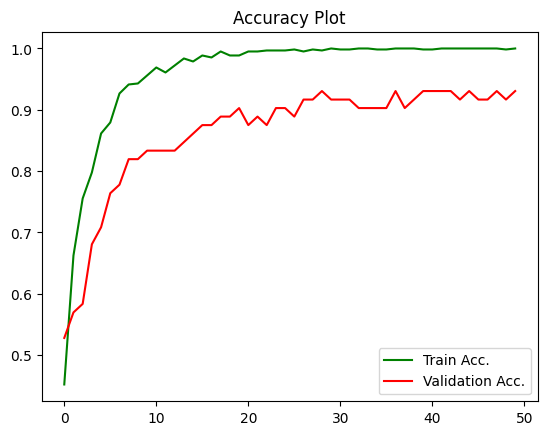

In [18]:
import matplotlib.pyplot as plt

plt.title('Accuracy Plot')

plt.plot(history.history['accuracy'], color='green', label='Train Acc.')
plt.plot(history.history['val_accuracy'], color='red', label='Validation Acc.')

plt.legend()
plt.show()

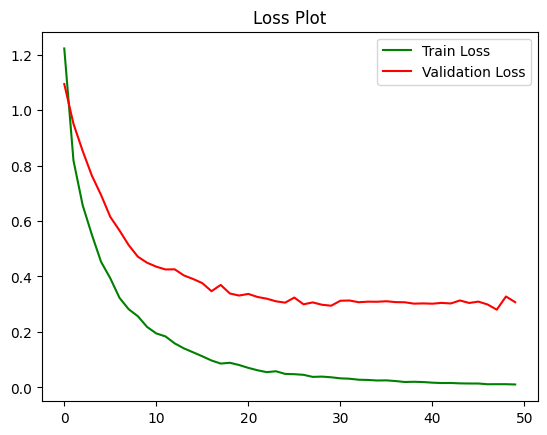

In [19]:
import matplotlib.pyplot as plt

plt.title('Loss Plot')

plt.plot(history.history['loss'], color='green', label='Train Loss')
plt.plot(history.history['val_loss'], color='red', label='Validation Loss')

plt.legend()
plt.show()

In [20]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print("Test accuracy:", test_accuracy)

40/40 ━━━━━━━━━━━━━━━━━━━━ 12s 286ms/step - accuracy: 0.8921 - loss: 0.3422
Test accuracy: 0.8920634984970093


In [21]:
model.save('./model_v3.keras')
print('Model Saved Succesfully')

Model Saved Succesfully
